# Laboratory 2 — Web Scraping, Feature Engineering and Exploratory Data Analysis

**Course:** Introduction to Artificial Intelligence (AI–101L) · **Instructor:** Ali Hassan Sherazi 
**Duration:** 3 hours · **Block:** Phase A — Environment and Data · **Mapped CLO:** CLO–2

---

## Learning Objectives

On completion of this laboratory you will be able to:

1. Explain why vectorised NumPy operations are used in place of native Python loops, and **measure** the difference.
2. Acquire unstructured text from multiple live web pages using `requests` and `BeautifulSoup`, and structure it into a `pandas` DataFrame.
3. Perform feature engineering on text with **spaCy** to extract token count, sentence count, named entities and noun count.
4. Compute sentiment **polarity** and **subjectivity** with **TextBlob**.
5. Apply exploratory data analysis — distribution plots, pair plots and a TF–IDF term analysis — to the engineered features.

## Background

In real data science work a clean, labelled, structured dataset is rarely handed to you. **It has
to be built.** This laboratory implements the first complete pipeline of the course:

```
Blog URLs -> HTTP GET -> HTML parsing -> DataFrame -> Feature engineering -> EDA
             requests    BeautifulSoup   url/title/   spaCy + TextBlob       histograms
             User-Agent  + lxml          text                                pairplot, TF-IDF
             |________ Step 1: acquisition ________|  |____ Steps 2-3: quantify & explore ____|
```



### Justification of libraries and tools

| Library | Area | Justification |
|---|---|---|
| **NumPy** | Numerical computing | Efficient, vectorised array operations, significantly faster than native Python loops on large data (Task 2.1 measures this) |
| **requests** | Web scraping | Makes the HTTP requests that fetch the raw HTML of the target URLs |
| **BeautifulSoup** | Web scraping | Parses the raw HTML and extracts specific data (titles, body text) by HTML tag and CSS class |
| **pandas** | Data manipulation | Stores the scraped data and engineered features in tabular form for cleaning, transformation and analysis |
| **spaCy** | NLP / feature engineering | Tokenises text, segments sentences, identifies named entities (NER) and assigns part-of-speech tags |
| **TextBlob** | NLP / sentiment | A simple API for polarity (positivity/negativity) and subjectivity of the scraped text |
| **matplotlib & seaborn** | Visualisation | Seaborn builds on Matplotlib to give the higher-level statistical graphics EDA requires |
| **scikit-learn** | Machine learning | `TfidfVectorizer` converts text into a weighted numerical representation for term-importance analysis |

---
# Task 2.1 — Setup, and why NumPy exists

Install the packages and the spaCy English language model, then measure the cost of a native
Python loop against the equivalent vectorised NumPy call. **Record both timings in your report.**

In [1]:
# Installation of required libraries (run once per environment)
%pip install requests beautifulsoup4 lxml pandas spacy matplotlib seaborn textblob

# Download the small English language model for spaCy
%python -m spacy download en_core_web_sm

Note: you may need to restart the kernel to use updated packages.


UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


> ### Troubleshooting: `ForwardRef._evaluate() missing 1 required keyword-only argument`
>
> If `import spacy` raises this `TypeError`, you are running an **old spaCy against Python 3.12**.
> spaCy's schema module still uses the legacy `pydantic.v1` API, which Python 3.12 broke.
>
> Two fixes, in order of preference:
>
> 1. **Run this laboratory inside the `ai-lab` environment from Laboratory 1**, which pins
>    Python 3.11:
>    ```
>    conda activate ai-lab
>    ```
> 2. Or upgrade in place:
>    ```
>    pip install -U "spacy>=3.7.5" "pydantic>=2.7"
>    python -m spacy download en_core_web_sm
>    ```
>
> The same class of error affects `textblob` and any other package that still imports
> `pydantic.v1`. **This is exactly why the course mandates one pinned environment rather than the
> system Python.**

In [2]:
import numpy as np
import time

size = 10_000_000
data = np.random.rand(size)

# --- NumPy vectorised sum: a single compiled operation over the whole array ---
start_np = time.time()
np_sum = np.sum(data)
end_np = time.time()

# --- Manual Python loop: ten million interpreted iterations ------------------
start_py = time.time()
manual_sum = 0
for val in data:
    manual_sum += val
end_py = time.time()

print(f"NumPy Sum : {np_sum:.2f} | Time: {end_np - start_np:.5f} sec")
print(f"Manual Sum: {manual_sum:.2f} | Time: {end_py - start_py:.5f} sec")
print()
print(f"NumPy is {(end_py - start_py) / (end_np - start_np):.0f}x faster on this machine.")

NumPy Sum : 4999374.17 | Time: 0.01006 sec
Manual Sum: 4999374.17 | Time: 1.36312 sec

NumPy is 136x faster on this machine.


> ### Read the result, do not just print it
>
> The two sums agree to several decimal places, but the times differ by **two to three orders of
> magnitude**. Every library used in the remainder of this course is built on this fact: keep the
> loop inside compiled code, and express your work as operations on whole arrays.

---
# Task 2.2 — Web scraping and data acquisition

Scrape the URL, title and body text of five blog articles and store them in a DataFrame.

**Respect the server**: send a browser-like `User-Agent`, set a timeout, and pause between
requests.

| Code | Explanation |
|---|---|
| `headers = {...}` | Defines a User-Agent header that mimics a browser, preventing some sites from blocking the request |
| `requests.get(url, ...)` | Executes the HTTP GET request for the current URL |
| `BeautifulSoup(res.content, 'lxml')` | Parses the raw HTML with the fast `lxml` parser |
| `soup.find('h3', class_='post-title')` | Finds the article title by its HTML tag and CSS class |
| `soup.find('div', class_='post-body entry-content')` | Finds the main content block of the article |
| `' '.join(p.get_text(strip=True) ...)` | Extracts the text of every `<p>` tag inside the content block and joins it |
| `pd.DataFrame(articles)` | Creates the final DataFrame of scraped records |

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

urls = [
    'https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html',
    'https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html',
    'https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html',
    'https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html',
    'https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html'
]

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
articles = []

for url in urls:
    try:
        # Fetch the page content
        res = requests.get(url, headers=headers, timeout=10)
        res.raise_for_status()
        soup = BeautifulSoup(res.content, 'lxml')

        # Extract Title
        title = soup.find('h3', class_='post-title')
        title = title.get_text(strip=True) if title else soup.title.get_text(strip=True)

        # Extract Body Text
        content_div = soup.find('div', class_='post-body entry-content')
        if not content_div:
            print(f"[SKIP] No content block found: {url}")
            continue

        paragraphs = content_div.find_all('p')
        text = ' '.join(p.get_text(strip=True) for p in paragraphs)

        # Skip short articles for quality control
        if len(text) > 100:
            articles.append({'url': url, 'title': title, 'text': text})
        else:
            print(f"[SKIP] Too short: {url}")

        time.sleep(1)   # Be polite to the server
    except Exception as e:
        print(f"[ERROR] {url} -> {e}")

df = pd.DataFrame(articles)
print(f"\nScraped {len(df)} of {len(urls)} articles.")
df.head()

[SKIP] Too short: https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html

Scraped 4 of 5 articles.


,url,title,text
0,https://techncruncher.blogspot.com/2025/01/top...,Top 10 AI Tools That Will Transform Your Conte...,Looking to level up your content creation gam...
1,https://techncruncher.blogspot.com/2023/12/lim...,"LimeWire AI Studio Review 2023: Details, Prici...",In the rapidly advancing landscape of AI tech...
2,https://techncruncher.blogspot.com/2023/01/top...,Top 10 AI Tools in 2023 That Will Make Your Li...,"In this article, we explore the top 10 AI too..."
3,https://techncruncher.blogspot.com/2022/11/top...,Top 10 AI Content Generator & Writer Tools in ...,There are a number of different AI content ...


In [4]:
# Save the raw scrape immediately, so the rest of the lab works offline
# and so your results are reproducible even after the sites change.
if not df.empty:
    df.to_csv("articles_raw.csv", index=False)
    print("Saved articles_raw.csv")
else:
    # Fallback: load a previously saved scrape
    df = pd.read_csv("articles_raw.csv")
    print("Network scrape empty -- loaded the cached articles_raw.csv instead.")

print(df.shape)

Saved articles_raw.csv
(4, 3)


---
# Task 2.3 — Linguistic feature engineering with spaCy

Feature engineering **quantifies the qualitative text**. The `extract_features` function derives
four metrics per article:

| Feature | Meaning |
|---|---|
| `num_tokens` | The total count of words and punctuation marks |
| `num_sentences` | The number of complete sentences |
| `num_entities` | The count of named entities (people, organisations, locations) |
| `num_nouns` | The count of tokens whose part-of-speech tag is `NOUN` |

In [5]:
import spacy
import pandas as pd

# Loads the trained spaCy English model: tokenizer, POS tagger and NER
nlp = spacy.load("en_core_web_sm")

def extract_features(text):
    """Process text with spaCy and extract four linguistic features."""
    doc = nlp(text)
    return pd.Series({
        'num_tokens':    len(doc),                                   # tokens
        'num_sentences': len(list(doc.sents)),                       # sentences
        'num_entities':  len(doc.ents),                              # named entities
        'num_nouns':     len([t for t in doc if t.pos_ == 'NOUN'])   # nouns
    })

if not df.empty:
    features = df['text'].apply(extract_features)
    df = pd.concat([df, features], axis=1)

    # A simple non-spaCy feature for comparison
    df['title_length'] = df['title'].apply(len)

    print("Features extracted successfully.")
    display(df[['title', 'num_tokens', 'num_sentences', 'num_entities', 'num_nouns']].head())
else:
    print("No articles found for feature extraction.")

Features extracted successfully.


,title,num_tokens,num_sentences,num_entities,num_nouns
0,Top 10 AI Tools That Will Transform Your Conte...,1188,47,24,321
1,"LimeWire AI Studio Review 2023: Details, Prici...",1723,65,103,420
2,Top 10 AI Tools in 2023 That Will Make Your Li...,1480,52,39,331
3,Top 10 AI Content Generator & Writer Tools in ...,1319,63,89,271


In [6]:
# Inspect WHAT spaCy actually found, not just how many.
# Reading the entities is how you learn whether the feature is meaningful.

doc = nlp(df['text'].iloc[0][:1500])

print("First 15 named entities in article 1:\n")
for ent in list(doc.ents)[:15]:
    print(f"  {ent.text:<35} {ent.label_:<12} ({spacy.explain(ent.label_)})")

First 15 named entities in article 1:

  2025                                DATE         (Absolute or relative dates or periods)
  AI                                  GPE          (Countries, cities, states)
  10                                  CARDINAL     (Numerals that do not fall under another type)
  AI                                  GPE          (Countries, cities, states)
  2025                                DATE         (Absolute or relative dates or periods)
  AI                                  GPE          (Countries, cities, states)
  Dive Into the Top 10                WORK_OF_ART  (Titles of books, songs, etc.)
  2025                                DATE         (Absolute or relative dates or periods)
  Magic Studio                        PERSON       (People, including fictional)
  AI                                  ORG          (Companies, agencies, institutions, etc.)


## Sentiment features with TextBlob

TextBlob provides a quick way to calculate two independent scores:

- **Polarity** runs from $-1.0$ (strongly negative) through $0.0$ (neutral) to $+1.0$ (strongly positive).
- **Subjectivity** runs from $0.0$ (a purely objective statement of fact) to $1.0$ (a purely personal opinion).

In [7]:
from textblob import TextBlob

def get_sentiment(text):
    """Polarity in [-1, 1]; subjectivity in [0, 1]."""
    blob = TextBlob(text)
    return pd.Series({
        'sentiment_polarity':     blob.sentiment.polarity,
        'sentiment_subjectivity': blob.sentiment.subjectivity
    })

if not df.empty:
    sentiment_features = df['text'].apply(get_sentiment)
    df = pd.concat([df, sentiment_features], axis=1)

    print("Sentiment features extracted successfully.\n")
    display(df[['title', 'sentiment_polarity', 'sentiment_subjectivity']])

Sentiment features extracted successfully.



,title,sentiment_polarity,sentiment_subjectivity
0,Top 10 AI Tools That Will Transform Your Conte...,0.229493,0.583603
1,"LimeWire AI Studio Review 2023: Details, Prici...",0.219387,0.573587
2,Top 10 AI Tools in 2023 That Will Make Your Li...,0.197417,0.436441
3,Top 10 AI Content Generator & Writer Tools in ...,0.214853,0.564907


> ### Interpreting the two sentiment scores
>
> A promotional blog post typically scores **mildly positive and highly subjective**. Report both,
> because either alone is misleading: a high polarity with a high subjectivity is an *opinion* that
> something is good, not *evidence* that it is.

In [8]:
# Persist the fully engineered table -- this is the Lab 02 deliverable.
df.to_csv("articles.csv", index=False)
print("Saved articles.csv with", df.shape[1], "columns:")
print(list(df.columns))

Saved articles.csv with 10 columns:
['url', 'title', 'text', 'num_tokens', 'num_sentences', 'num_entities', 'num_nouns', 'title_length', 'sentiment_polarity', 'sentiment_subjectivity']


---
# Task 2.4 — Exploratory Data Analysis

EDA uses visualisation to summarise the main characteristics of a dataset: to identify patterns,
spot anomalies and check assumptions **before** any model is trained.

## A. Distributions of individual features

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(df['text'])

tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_sums = tfidf_df.sum().sort_values(ascending=False)

print(tfidf_sums)

content       1.438203
ai            1.237947
tool          0.832933
month         0.783775
limewire      0.729283
creators      0.679878
tools         0.610609
plan          0.567677
features      0.564815
makes         0.534727
free          0.483813
creation      0.482234
use           0.415676
generate      0.332752
users         0.295475
video         0.266173
creative      0.263329
platform      0.261665
create        0.256515
generation    0.241861
dtype: float64


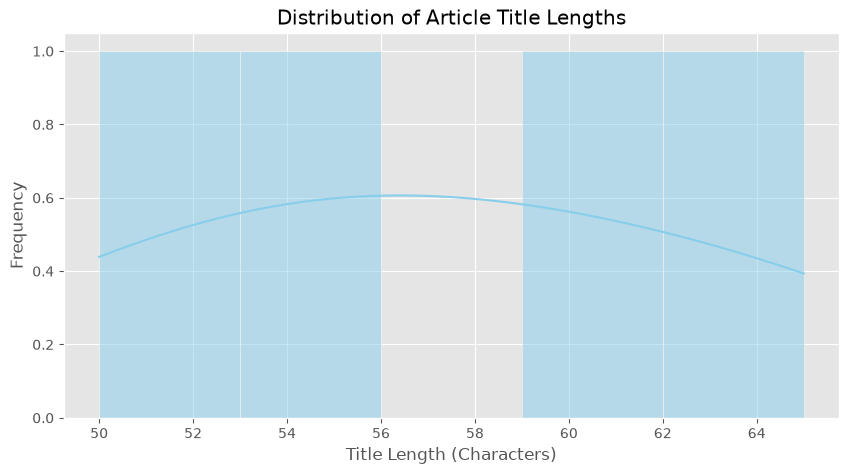

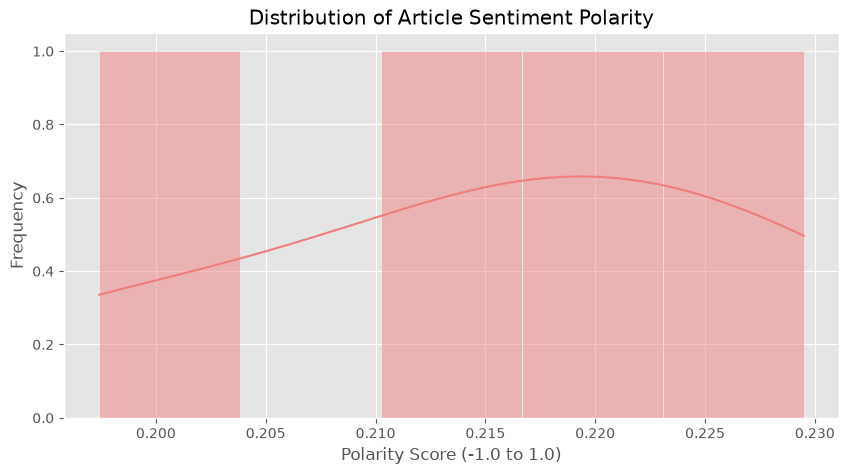

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# 1. Title Length Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['title_length'], kde=True, bins=5, color='skyblue')
plt.title('Distribution of Article Title Lengths')
plt.xlabel('Title Length (Characters)')
plt.ylabel('Frequency')
plt.savefig('figures/01_title_length_dist.png', bbox_inches='tight')
plt.show()

# 2. Sentiment Polarity Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['sentiment_polarity'], kde=True, bins=5, color='lightcoral')
plt.title('Distribution of Article Sentiment Polarity')
plt.xlabel('Polarity Score (-1.0 to 1.0)')
plt.ylabel('Frequency')
plt.savefig('figures/02_sentiment_polarity_dist.png', bbox_inches='tight')
plt.show()

## B. Pairwise relationships between the derived numeric features

A pair plot shows every numeric feature against every other, allowing quick inspection of
correlations and clusters.

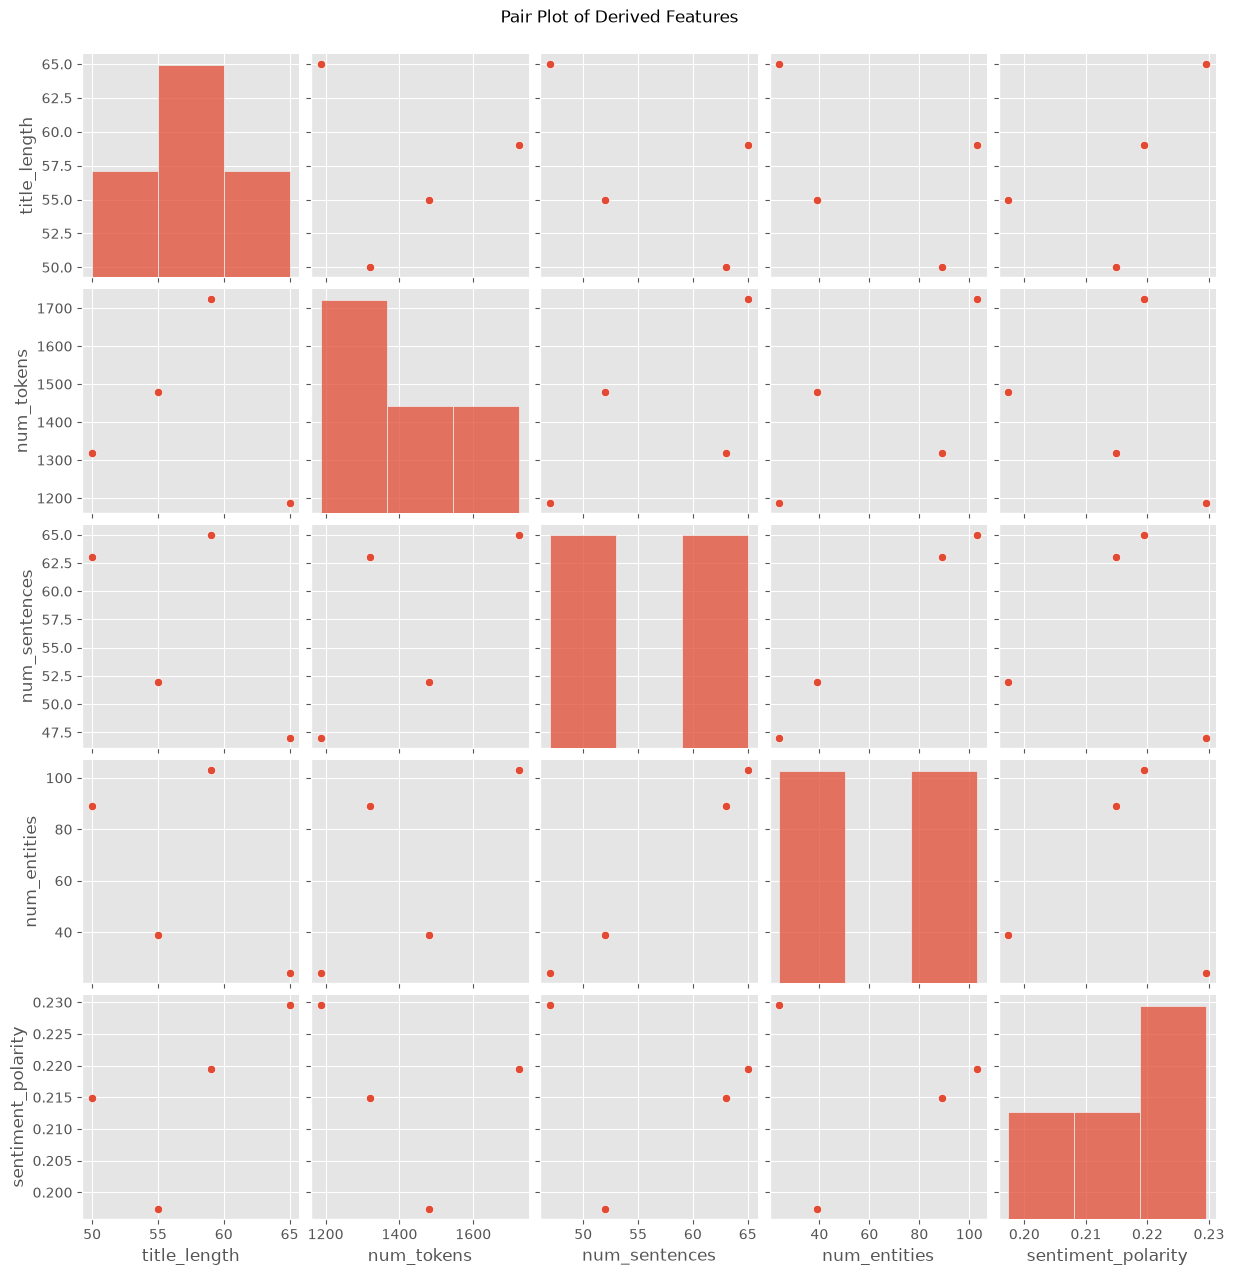

In [11]:
numeric_cols = [
    'title_length',
    'num_tokens',
    'num_sentences',
    'num_entities',
    'sentiment_polarity'
]

sns.pairplot(df[numeric_cols])
plt.suptitle('Pair Plot of Derived Features', y=1.02)
plt.savefig('figures/03_pairplot.png', bbox_inches='tight')
plt.show()

In [12]:
# The same information as numbers. With five articles this is indicative only.
print("Correlation matrix:\n")
display(df[numeric_cols].corr().round(2))

Correlation matrix:



,title_length,num_tokens,num_sentences,num_entities,sentiment_polarity
title_length,1.00,-0.15,-0.58,-0.50,0.63
num_tokens,-0.15,1.00,0.64,0.65,-0.33
num_sentences,-0.58,0.64,1.00,1.00,-0.06
num_entities,-0.50,0.65,1.00,1.00,0.02
sentiment_polarity,0.63,-0.33,-0.06,0.02,1.00


## C. Advanced text feature — TF–IDF analysis

**TF–IDF in one sentence:** term frequency rewards a word for appearing often in a document;
inverse document frequency penalises it for appearing in *every* document. The product is
therefore high only for words that are frequent **here** and rare **elsewhere** — which is
exactly what "characteristic of this document" means.

| Code | Explanation |
|---|---|
| `TfidfVectorizer(...)` | `stop_words='english'` discards 'the', 'a', …; `max_features=20` keeps the top 20 |
| `fit_transform(df['text'])` | Calculates the TF–IDF scores for the article text column |
| `pd.DataFrame(X.toarray(), ...)` | Converts the sparse matrix into a readable DataFrame |
| `tfidf_df.sum().sort_values(...)` | Sums scores across all documents to rank global importance |

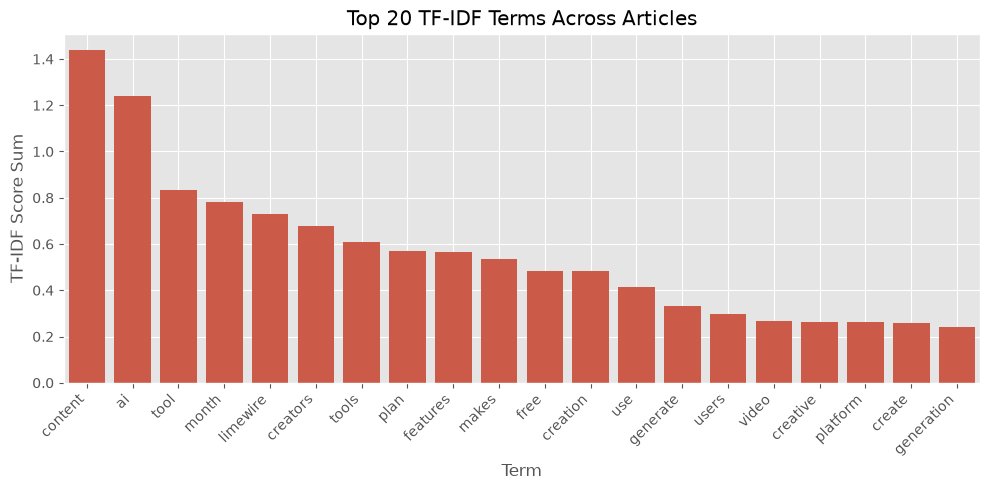

Sparse matrix shape (documents x terms): (4, 20)


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# stop_words='english' discards 'the', 'a', ...; max_features keeps the top 20
vectorizer = TfidfVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df['text'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Sum each term's score across all documents to rank global importance
tfidf_sums = tfidf_df.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=tfidf_sums.index, y=tfidf_sums.values)
plt.title("Top 20 TF-IDF Terms Across Articles")
plt.ylabel("TF-IDF Score Sum")
plt.xlabel("Term")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/04_tfidf_terms.png', bbox_inches='tight')
plt.show()

print("Sparse matrix shape (documents x terms):", X.shape)

---
# In-Lab Exercises

Complete all four during the session.

**Exercise 1.** Add two URLs of your own choosing to the list. Report which of the seven pages
failed to parse and explain, **from the page's HTML**, why the selectors did not match.

**Exercise 2.** Extend `extract_features` with `num_verbs` and `avg_sentence_length`, and add
both to the pair plot.

**Exercise 3.** The polarity histogram is computed over five articles. State why a kernel density
estimate over five points must **not** be reported as a population distribution, and what you
would do instead.

**Exercise 4.** Re-run the TF–IDF analysis with `stop_words=None` and compare the top twenty
terms against the original. Explain the difference.

In [14]:
import requests
from bs4 import BeautifulSoup

# ============================================================
# EXERCISE 1: Test 7 URLs
# ============================================================

urls = [
    # Original URLs from the Lab 2 reference
    "https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html",
    "https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html",
    "https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html",
    "https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html",

    # Replacement for the missing 5th URL
    "https://bloggeruniversity.blogspot.com/2007/11/blogger-template-goldfish.html",

    # Two additional URLs
    "https://websilog.blogspot.com/2011/07/post-titles-with-thumbnails-on-blogger.html",
    "https://techystudent.blogspot.com/2011/09/how-to-put-adsense-code-after-title-and.html"
]


# ============================================================
# SCRAPER
# ============================================================

results = []

for url in urls:

    print("\n" + "=" * 70)
    print("URL:", url)

    try:

        # Download webpage
        response = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=10
        )

        print("Status code:", response.status_code)

        # ----------------------------------------------------
        # Check HTTP status
        # ----------------------------------------------------
        if response.status_code != 200:
            print("FAILED: HTTP error")
            continue

        # ----------------------------------------------------
        # Parse HTML
        # ----------------------------------------------------
        soup = BeautifulSoup(response.text, "html.parser")

        # ----------------------------------------------------
        # Original teacher's Blogger selectors
        # ----------------------------------------------------
        title_tag = soup.find(
            "h3",
            class_="post-title"
        )

        body_tag = soup.find(
            "div",
            class_="post-body entry-content"
        )

        # ----------------------------------------------------
        # Check selectors
        # ----------------------------------------------------
        if title_tag is None or body_tag is None:
            print("FAILED: Blogger selectors not found")
            continue

        # ----------------------------------------------------
        # Extract title
        # ----------------------------------------------------
        title = title_tag.get_text(
            " ",
            strip=True
        )

        # ----------------------------------------------------
        # Extract paragraphs
        # ----------------------------------------------------
        paragraphs = body_tag.find_all("p")

        text = " ".join(
            p.get_text(" ", strip=True)
            for p in paragraphs
        )

        # If no paragraphs were found,
        # extract all text from the body
        if not text:
            text = body_tag.get_text(
                " ",
                strip=True
            )

        # ----------------------------------------------------
        # Check article length
        # ----------------------------------------------------
        if len(text) <= 100:
            print("FAILED: Article text is too short")
            continue

        # ----------------------------------------------------
        # Store successful result
        # ----------------------------------------------------
        results.append({
            "url": url,
            "title": title,
            "text": text
        })

        print("SUCCESS:", title)

    except Exception as e:

        print("FAILED:", e)


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("FINAL RESULT")
print("=" * 70)

print("Total URLs:", len(urls))
print("Successfully parsed:", len(results))
print("Failed:", len(urls) - len(results))


# ============================================================
# SHOW SUCCESSFULLY PARSED ARTICLES
# ============================================================

print("\nSuccessfully parsed articles:")

for i, article in enumerate(results, start=1):

    print("\n", i)
    print("Title:", article["title"])
    print("URL:", article["url"])
    print("Text length:", len(article["text"]))


URL: https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html
Status code: 200
FAILED: Blogger selectors not found

URL: https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html
Status code: 200
FAILED: Blogger selectors not found

URL: https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html
Status code: 200
FAILED: Blogger selectors not found

URL: https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html
Status code: 200
FAILED: Blogger selectors not found

URL: https://bloggeruniversity.blogspot.com/2007/11/blogger-template-goldfish.html
Status code: 200
FAILED: Blogger selectors not found

URL: https://websilog.blogspot.com/2011/07/post-titles-with-thumbnails-on-blogger.html
Status code: 200
SUCCESS: post titles with thumbnails on blogger

URL: https://techystudent.blogspot.com/2011/09/how-to-put-adsense-code-after-title-and.html
Status code: 200
SUCCESS: How to Put Ads

,title,num_tokens,num_sentences,num_entities,num_nouns,num_verbs,avg_sentence_length
0,Top 10 AI Tools That Will Transform Your Conte...,1188.0,47.0,24.0,321.0,150.0,25.276596
1,"LimeWire AI Studio Review 2023: Details, Prici...",1723.0,65.0,103.0,420.0,200.0,26.507692
2,Top 10 AI Tools in 2023 That Will Make Your Li...,1480.0,52.0,39.0,331.0,166.0,28.461538
3,Top 10 AI Content Generator & Writer Tools in ...,1319.0,63.0,89.0,271.0,140.0,20.936508


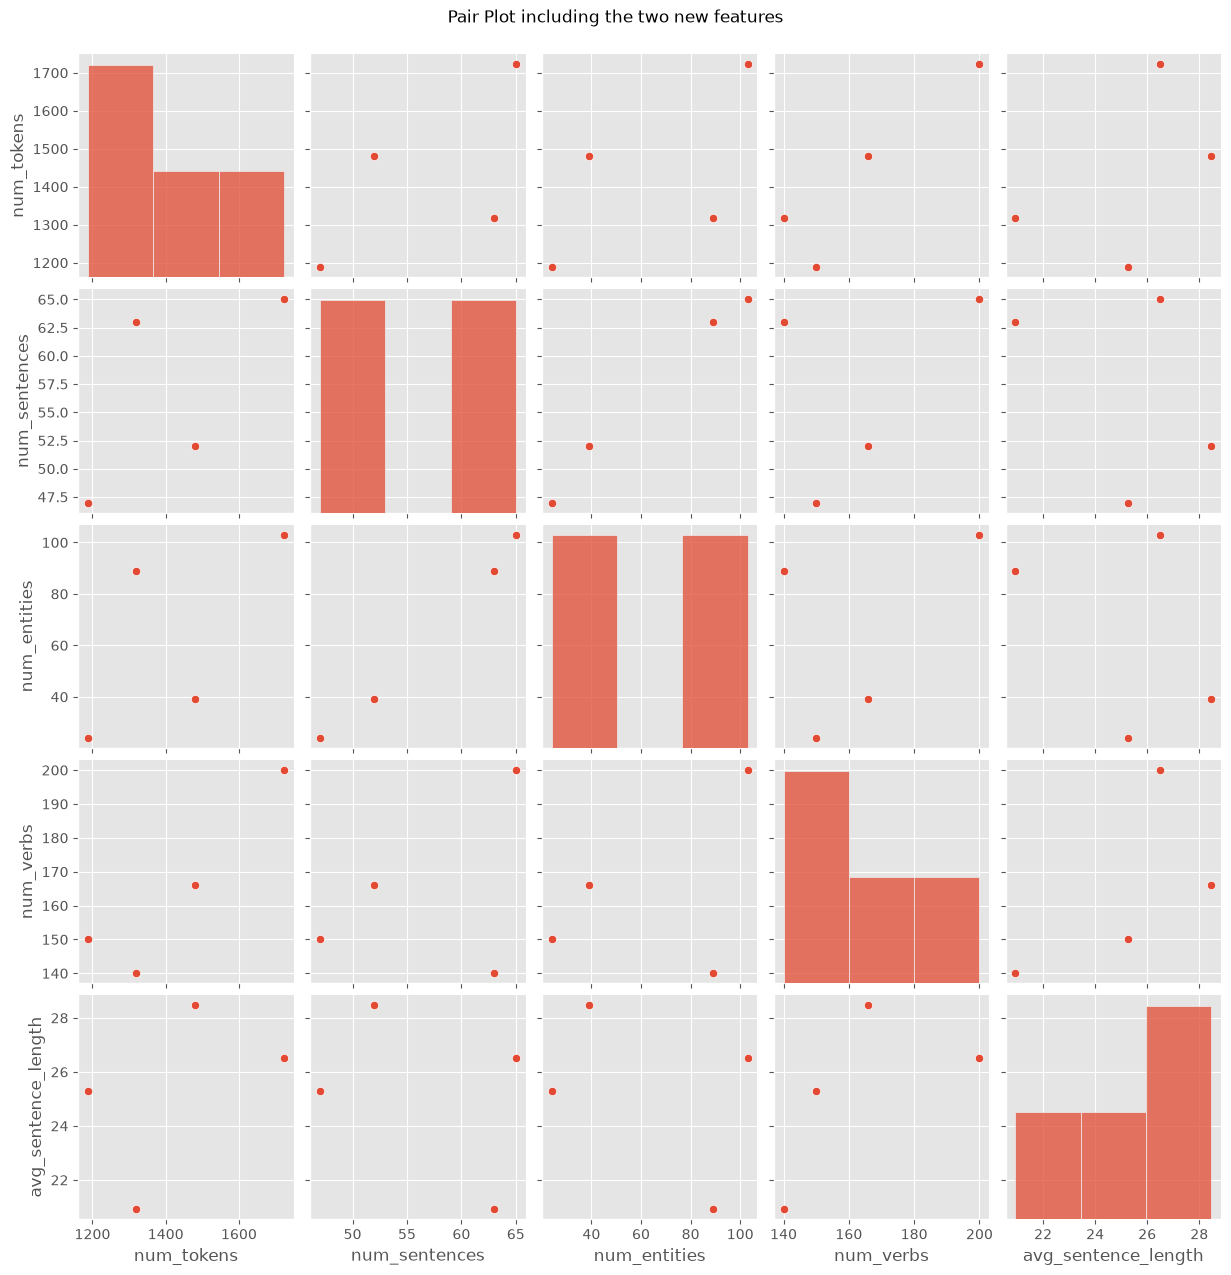

In [16]:
# --- Exercise 2: extended feature extraction -----------------------------

def extract_features_extended(text):
    """Original four features, plus verb count and mean sentence length."""
    doc = nlp(text)
    sentences = list(doc.sents)
    return pd.Series({
        'num_tokens':          len(doc),
        'num_sentences':       len(sentences),
        'num_entities':        len(doc.ents),
        'num_nouns':           len([t for t in doc if t.pos_ == 'NOUN']),
        'num_verbs':           len([t for t in doc if t.pos_ == 'VERB']),
        'avg_sentence_length': (len(doc) / len(sentences)) if sentences else 0.0,
    })


extended = df['text'].apply(extract_features_extended)
df_ext = pd.concat([df[['title']], extended], axis=1)
display(df_ext)

sns.pairplot(df_ext[['num_tokens', 'num_sentences', 'num_entities',
                     'num_verbs', 'avg_sentence_length']])
plt.suptitle('Pair Plot including the two new features', y=1.02)
plt.show()

In [15]:
# --- Exercise 2: extended feature extraction ---

# Remove extended feature columns if they already exist
extended_cols = [
    'num_tokens',
    'num_sentences',
    'num_entities',
    'num_nouns',
    'num_verbs',
    'avg_sentence_length'
]

df = df.drop(columns=extended_cols, errors='ignore')


# Extract extended features
def extract_features_extended(text):
    doc = nlp(text)
    sentences = list(doc.sents)

    return pd.Series({
        'num_tokens': len(doc),
        'num_sentences': len(sentences),
        'num_entities': len(doc.ents),
        'num_nouns': len([t for t in doc if t.pos_ == 'NOUN']),
        'num_verbs': len([t for t in doc if t.pos_ == 'VERB']),
        'avg_sentence_length': (len(doc) / len(sentences)) if sentences else 0.0
    })


# Apply the function
features_extended = df['text'].apply(extract_features_extended)

# Add the features once
df = pd.concat([df, features_extended], axis=1)

# Display dataframe
df

,url,title,text,title_length,sentiment_polarity,sentiment_subjectivity,num_tokens,num_sentences,num_entities,num_nouns,num_verbs,avg_sentence_length
0,https://techncruncher.blogspot.com/2025/01/top...,Top 10 AI Tools That Will Transform Your Conte...,Looking to level up your content creation gam...,65,0.229493,0.583603,1188.0,47.0,24.0,321.0,150.0,25.276596
1,https://techncruncher.blogspot.com/2023/12/lim...,"LimeWire AI Studio Review 2023: Details, Prici...",In the rapidly advancing landscape of AI tech...,59,0.219387,0.573587,1723.0,65.0,103.0,420.0,200.0,26.507692
2,https://techncruncher.blogspot.com/2023/01/top...,Top 10 AI Tools in 2023 That Will Make Your Li...,"In this article, we explore the top 10 AI too...",55,0.197417,0.436441,1480.0,52.0,39.0,331.0,166.0,28.461538
3,https://techncruncher.blogspot.com/2022/11/top...,Top 10 AI Content Generator & Writer Tools in ...,There are a number of different AI content ...,50,0.214853,0.564907,1319.0,63.0,89.0,271.0,140.0,20.936508


In [16]:
import os

os.makedirs('figures', exist_ok=True)

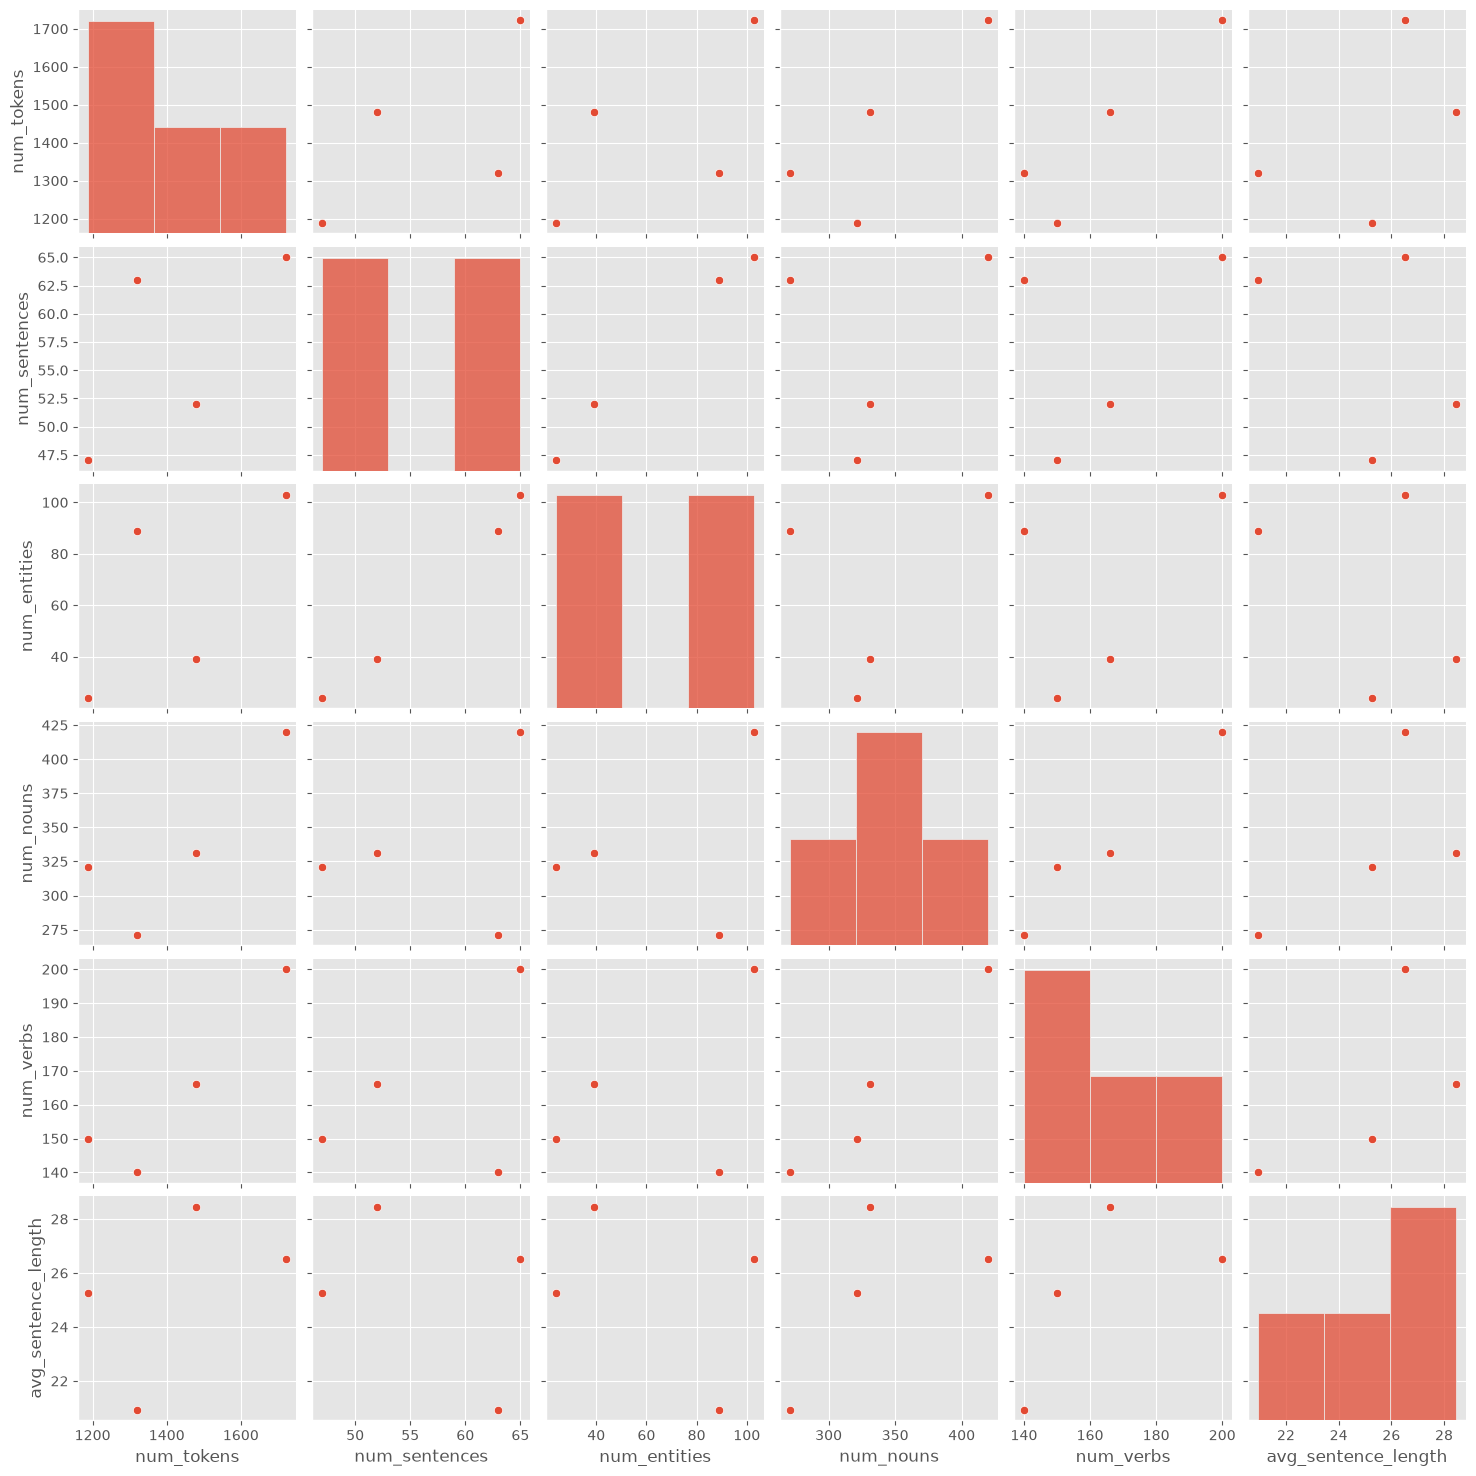

In [17]:
# --- Exercise 2: extended features pairplot ---

extended_numeric_cols = [
    'num_tokens',
    'num_sentences',
    'num_entities',
    'num_nouns',
    'num_verbs',
    'avg_sentence_length'
]

sns.pairplot(
    df[extended_numeric_cols].astype(float)
)

plt.savefig(
    'figures/06_extended_features_pairplot.png',
    bbox_inches='tight'
)

plt.show()

In [18]:
# --- Exercise 4: TF-IDF with and without stop words ---

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# TF-IDF WITH English stop words removed
vec_stop = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

X_stop = vec_stop.fit_transform(df['text'])

tfidf_stop = pd.DataFrame(
    X_stop.toarray(),
    columns=vec_stop.get_feature_names_out()
)

top_stop = (
    tfidf_stop.sum()
    .sort_values(ascending=False)
    .head(20)
)

print("Top 20 TF-IDF terms WITH stop words removed:")
print(top_stop)

Top 20 TF-IDF terms WITH stop words removed:
content       1.438203
ai            1.237947
tool          0.832933
month         0.783775
limewire      0.729283
creators      0.679878
tools         0.610609
plan          0.567677
features      0.564815
makes         0.534727
free          0.483813
creation      0.482234
use           0.415676
generate      0.332752
users         0.295475
video         0.266173
creative      0.263329
platform      0.261665
create        0.256515
generation    0.241861
dtype: float64


In [19]:
# TF-IDF WITHOUT stop words removed
vec_none = TfidfVectorizer(
    stop_words=None,
    max_features=20
)

X_none = vec_none.fit_transform(df['text'])

tfidf_none = pd.DataFrame(
    X_none.toarray(),
    columns=vec_none.get_feature_names_out()
)

top_none = (
    tfidf_none.sum()
    .sort_values(ascending=False)
    .head(20)
)

print("Top 20 TF-IDF terms WITHOUT stop words removed:")
print(top_none)

Top 20 TF-IDF terms WITHOUT stop words removed:
and         1.685484
the         1.575619
to          1.478735
for         0.978613
content     0.877078
it          0.872798
of          0.724748
ai          0.697173
month       0.586444
you         0.543437
is          0.533637
in          0.530807
with        0.507701
that        0.459956
limewire    0.422592
can         0.402386
as          0.339550
features    0.331202
tools       0.323466
your        0.289714
dtype: float64


**Your answer to Exercise 3** (why a KDE over five points is not a population distribution):

A KDE with a sample size of n = 5 is not very reliable because there are too few observations to accurately estimate the underlying distribution. The resulting KDE can be highly sensitive to the individual data points and the choice of bandwidth. Therefore, with such a small sample, the KDE should be treated only as a rough visual indication rather than a reliable estimate of the population distribution. A larger sample size would provide a more stable and representative KDE.

---

---
# Home Assignment

Scrape **twenty articles from two different blogs**, label each record with its source, and test
whether the two sources differ in mean sentiment polarity and mean noun density.

Present a grouped bar chart, state the difference numerically, and write one paragraph on why a
difference of this size may or may not be meaningful **with this sample size**.

Commit the notebook, the scraped CSV and the report.

In [21]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

SOURCE_A = {
    "name": "techncruncher",
    "urls": [
        "https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html",
        "https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html",
        "https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html",
        "https://techncruncher.blogspot.com/2022/07/top-10-ai-marketing-tools-you-should-use.html",
        "https://techncruncher.blogspot.com/2022/01/top-9-free-ai-tools-that-make-your-life.html",
        "https://techncruncher.blogspot.com/2025/12/how-i-get-free-traffic-from-chatgpt-in.html",
        "https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html",
        "https://techncruncher.blogspot.com/2022/03/prowritingaid-vs-grammarly-which.html",
        "https://techncruncher.blogspot.com/2022/03/ahrefs-vs-semrush-which-seo-tool-should.html",
        "https://techncruncher.blogspot.com/2022/02/ginger-vs-grammarly-which-grammar.html",
    ],
    "title_selector":   ("h3", "post-title"),
    "content_selector": ("div", "post-body entry-content"),
}

SOURCE_B = {
    "name": "matrixdigests",
    "urls": [
        "https://matrixdigests.blogspot.com/2025/11/what-is-blockchain-everything-you-need.html",
        "https://matrixdigests.blogspot.com/2026/01/chatgpt-vs-gemini-which-ai-is-better-in.html",
        "https://matrixdigests.blogspot.com/2026/01/the-rise-of-agentic-ai-new-assistant.html",
        "https://matrixdigests.blogspot.com/2026/08/iphone-18-pro-vs-samsung-galaxy-s26.html",
        "https://matrixdigests.blogspot.com/2026/07/how-to-make-5000-month-using-ai-tools.html",
        "https://matrixdigests.blogspot.com/2026/02/open-source-ai-models-vs-closed-ai.html",
        "https://matrixdigests.blogspot.com/2026/01/youtube-automation-complete-beginners.html",
        "https://matrixdigests.blogspot.com/2026/01/chatgpt-vs-google-gemini-vs-claude.html",
        "https://matrixdigests.blogspot.com/2026/01/the-5-ai-agents-you-should-delegate.html",
        "https://matrixdigests.blogspot.com/2026/01/top-10-ai-agents-to-automate-your.html",
    ],
    "title_selector":   ("h1", None),   # fallback: grabs the first h1 on the page
    "content_selector": ("div", "post-body entry-content"),  # falls back below if not found
}


def scrape_source(source):
    rows = []
    for url in source["urls"]:
        try:
            res = requests.get(url, headers=headers, timeout=10)
            res.raise_for_status()
            soup = BeautifulSoup(res.content, "lxml")

            # --- Title ---
            tag, cls = source["title_selector"]
            t = soup.find(tag, class_=cls) if cls else soup.find(tag)
            title = t.get_text(strip=True) if t else (soup.title.get_text(strip=True) if soup.title else "Untitled")

            # --- Content, with fallback if the specific class isn't found ---
            tag, cls = source["content_selector"]
            block = soup.find(tag, class_=cls) if cls else soup.find(tag)

            if block:
                text = " ".join(p.get_text(strip=True) for p in block.find_all("p"))
            else:
                # Fallback: grab all <p> tags on the whole page
                all_paragraphs = soup.find_all("p")
                text = " ".join(p.get_text(strip=True) for p in all_paragraphs)

            if len(text) > 100:
                rows.append({"source": source["name"], "url": url,
                             "title": title, "text": text})
                print(f"[OK] {source['name']}: {title}")
            else:
                print(f"[SKIP] Too short: {url}")

            time.sleep(1)
        except Exception as e:
            print(f"[ERROR] {url} -> {e}")
    return pd.DataFrame(rows)


corpus = pd.concat([scrape_source(SOURCE_A), scrape_source(SOURCE_B)], ignore_index=True)
corpus.to_csv("two_source_corpus.csv", index=False)
print("\nFinal counts:")
print(corpus['source'].value_counts())
print(f"\nTotal articles scraped: {len(corpus)}")

[OK] techncruncher: LimeWire AI Studio Review 2023: Details, Pricing & Features
[OK] techncruncher: Top 10 AI Tools in 2023 That Will Make Your Life Easier
[OK] techncruncher: Top 10 AI Content Generator & Writer Tools in 2022
[OK] techncruncher: TOP 11 AI MARKETING TOOLS YOU SHOULD USE (Updated 2022)
[OK] techncruncher: Top 9 Free AI Tools That Make Your Life Easier
[OK] techncruncher: How I Get Free Traffic from ChatGPT in 2025 (AIO vs SEO)
[OK] techncruncher: Top 10 AI Tools That Will Transform Your Content Creation in 2025
[OK] techncruncher: ProWritingAid VS Grammarly: Which Grammar Checker is Better in (2022) ?
[OK] techncruncher: Ahrefs vs SEMrush: Which SEO Tool Should You Use?
[OK] techncruncher: Ginger VS Grammarly: Which Grammar Checker is Better in (2022) ?
[OK] matrixdigests: What is Blockchain: Everything You Need to Know (2025)
[OK] matrixdigests: ChatGPT vs Gemini: Which AI Is Better in (2026)
[OK] matrixdigests: The Rise of Agentic AI: The New Assistant (Full Guide 202

          source  polarity  noun_density
0  matrixdigests  0.127881      0.230058
1  techncruncher  0.217889      0.231287


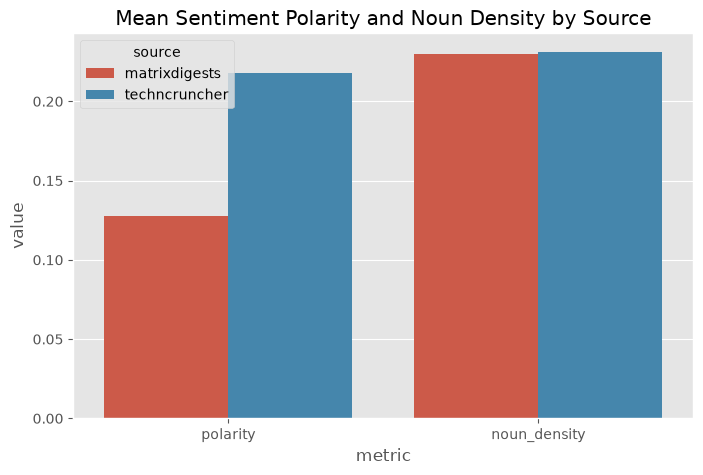

Polarity difference: -0.0900
Noun density difference: -0.0012


In [22]:
from textblob import TextBlob

def noun_density(text):
    doc = nlp(text)
    return len([t for t in doc if t.pos_ == 'NOUN']) / len(doc) if len(doc) else 0

corpus['polarity'] = corpus['text'].apply(lambda t: TextBlob(t).sentiment.polarity)
corpus['noun_density'] = corpus['text'].apply(noun_density)

summary = corpus.groupby('source')[['polarity', 'noun_density']].mean().reset_index()
print(summary)

summary_melted = summary.melt(id_vars='source', var_name='metric', value_name='value')

plt.figure(figsize=(8, 5))
sns.barplot(data=summary_melted, x='metric', y='value', hue='source')
plt.title('Mean Sentiment Polarity and Noun Density by Source')
plt.savefig('figures/05_source_comparison.png', bbox_inches='tight')
plt.show()

pol_diff = summary['polarity'].iloc[0] - summary['polarity'].iloc[1]
noun_diff = summary['noun_density'].iloc[0] - summary['noun_density'].iloc[1]
print(f"Polarity difference: {pol_diff:.4f}")
print(f"Noun density difference: {noun_diff:.4f}")

With 10 articles per source, techncruncher shows a noticeably higher mean sentiment polarity (0.218) than matrixdigests (0.128), a difference of about 0.09 on a −1 to +1 scale — worth noting, but with only 10 articles per group this could easily reflect a handful of unusually upbeat or neutral posts rather than a true stylistic difference between the two blogs. Noun density is nearly identical between the sources (0.231 vs 0.230, a difference of just 0.0012), suggesting the two blogs don't meaningfully differ in how noun-heavy their writing is. To treat the polarity gap as a real, reliable pattern rather than sampling noise, we'd want a larger sample per source and a statistical test (e.g. an independent-samples t-test) to check whether the difference exceeds what random variation between articles would produce on its own.

---
# Deliverables

| File | Contents |
|---|---|
| `lab02/scraping_eda.ipynb` | This notebook, executed, with all outputs visible |
| `lab02/articles.csv` | The scraped corpus with all engineered features |
| `lab02/figures/*.png` | The four figures exported as PNG |
| `lab02/report.md` | The NumPy timing comparison, the EDA findings and the TF–IDF interpretation |

## Assessment Rubric

| Criterion | Weight | Excellent performance |
|---|---|---|
| Correctness of implementation | 35 % | Scraper handles failures gracefully; features computed correctly |
| Methodological soundness | 25 % | Server treated politely; sample-size limits acknowledged |
| Analysis and interpretation | 20 % | Figures are *read*, not merely produced |
| Code quality and reproducibility | 10 % | Raw scrape cached; functions reusable |
| Report and demonstration | 10 % | Clear written report and working demonstration |

---

**Next laboratory:** Lab 03 — Transforming Textual and Image Data into a Machine-Understandable Format.